## Project Introduction
- Neural Network Based Project Status Prediction
- using TensorFlow and Keras



## Import Libraries

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Dense

## Load Dataset

In [5]:
df = pd.read_csv(
    "coretech_project_dataset.csv"
)

df.head()

,Client_ID,Employees,Annual_Revenue,Projects_Completed,Years_With_Company,Customer_Satisfaction,Project_Status
0,1001,122,663333,37,7,62,Failed
1,1002,455,608986,22,6,92,Completed
2,1003,368,160078,29,12,52,Failed
3,1004,290,917055,14,1,82,Completed
4,1005,126,72671,28,5,55,Failed


## Dataset Overview

In [6]:
df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Client_ID              300 non-null    int64 
 1   Employees              300 non-null    int64 
 2   Annual_Revenue         300 non-null    int64 
 3   Projects_Completed     300 non-null    int64 
 4   Years_With_Company     300 non-null    int64 
 5   Customer_Satisfaction  300 non-null    int64 
 6   Project_Status         300 non-null    object
dtypes: int64(6), object(1)
memory usage: 16.5+ KB


,Client_ID,Employees,Annual_Revenue,Projects_Completed,Years_With_Company,Customer_Satisfaction
count,300.000000,300.000000,300.000000,300.00000,300.000000,300.000000
mean,1150.500000,260.790000,504241.443333,25.59000,7.256667,74.486667
std,86.746758,135.105035,275110.394909,13.87095,4.048715,14.476015
min,1001.000000,21.000000,52869.000000,1.00000,1.000000,50.000000
25%,1075.750000,149.000000,246170.500000,13.00000,4.000000,61.000000
50%,1150.500000,254.000000,499188.500000,26.00000,7.000000,76.000000
75%,1225.250000,372.750000,741958.500000,36.00000,11.000000,86.250000
max,1300.000000,496.000000,999597.000000,49.00000,14.000000,99.000000


## Class Distribution

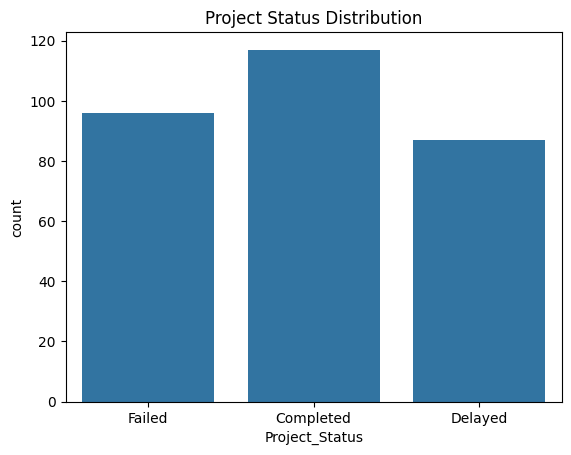

In [7]:
sns.countplot(
    x="Project_Status",
    data=df
)

plt.title(
    "Project Status Distribution"
)

plt.savefig(
    "class_distribution.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Feature Selection

In [8]:
X = df[

    [
        "Employees",
        "Annual_Revenue",
        "Projects_Completed",
        "Years_With_Company",
        "Customer_Satisfaction"
    ]

]

## Label Encoding

In [9]:
encoder = LabelEncoder()

y = encoder.fit_transform(
    df["Project_Status"]
)

y

array([2, 0, 2, 0, 2, 0, 2, 2, 1, 2, 0, 2, 2, 0, 2, 1, 2, 0, 2, 1, 2, 2,
       2, 1, 0, 0, 1, 1, 0, 2, 0, 0, 2, 2, 2, 0, 2, 0, 0, 2, 0, 1, 1, 2,
       2, 0, 0, 2, 1, 0, 1, 0, 2, 1, 2, 1, 2, 1, 0, 0, 1, 1, 0, 2, 0, 0,
       2, 0, 0, 0, 1, 2, 0, 1, 1, 0, 0, 2, 2, 0, 0, 0, 2, 2, 2, 2, 2, 0,
       2, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 2, 1, 2, 2, 2, 2, 0, 0,
       2, 1, 0, 0, 0, 1, 2, 1, 2, 2, 1, 0, 2, 2, 0, 2, 1, 1, 0, 0, 1, 0,
       1, 2, 1, 2, 2, 0, 0, 2, 2, 1, 0, 1, 0, 0, 2, 1, 2, 0, 1, 1, 0, 0,
       0, 0, 2, 0, 0, 0, 2, 2, 0, 2, 0, 0, 1, 1, 2, 1, 2, 0, 0, 1, 2, 1,
       2, 0, 0, 1, 1, 0, 0, 1, 2, 0, 2, 1, 0, 2, 2, 2, 1, 0, 0, 1, 1, 2,
       0, 2, 2, 1, 1, 0, 1, 1, 0, 0, 1, 1, 2, 2, 1, 0, 0, 1, 0, 1, 1, 1,
       0, 1, 0, 2, 1, 1, 0, 0, 1, 1, 1, 0, 0, 2, 2, 0, 2, 1, 1, 1, 0, 1,
       1, 0, 0, 1, 1, 2, 0, 1, 1, 2, 2, 0, 0, 2, 1, 0, 0, 1, 0, 2, 2, 2,
       1, 0, 2, 0, 2, 2, 1, 0, 0, 0, 1, 1, 0, 0, 2, 1, 2, 2, 2, 1, 1, 2,
       0, 0, 2, 0, 1, 0, 2, 0, 0, 0, 1, 2, 0, 0])

## Standardization

In [10]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

## Train Test Split

In [12]:
X_train,X_test,y_train,y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42
)

## Build ANN

### Artificial Neural Network Architecture

An Artificial Neural Network (ANN) was developed using TensorFlow and Keras to predict project status based on client and project-related features.

The network consists of multiple hidden layers with ReLU activation functions, enabling the model to learn complex nonlinear relationships within the dataset. A Softmax output layer was used because the target variable contains multiple classes.

The objective is to classify project outcomes into Completed, Delayed, and Failed categories.

In [13]:
model = Sequential()

model.add(

    Dense(
        64,
        activation='relu',
        input_shape=(5,)
    )

)

model.add(

    Dense(
        32,
        activation='relu'
    )

)

model.add(

    Dense(
        16,
        activation='relu'
    )

)

model.add(

    Dense(
        3,
        activation='softmax'
    )

)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Compile Model

In [14]:
model.compile(

    optimizer='adam',

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']

)

## Model Summary

In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,043 (11.89 KB)

 Trainable params: 3,043 (11.89 KB)

 Non-trainable params: 0 (0.00 B)

#### Model Architecture Analysis

The neural network contains three hidden layers with decreasing neuron sizes.

This architecture enables the model to gradually extract higher-level feature representations while reducing dimensional complexity.

The use of ReLU activation improves training efficiency and helps address vanishing gradient issues commonly encountered in deep learning models.

## Train Model

#### Model Training

The neural network was trained using the Adam optimizer and Sparse Categorical Crossentropy loss function.

Training was performed for multiple epochs while monitoring validation performance to evaluate how effectively the model learns patterns from the dataset.

Both training accuracy and validation accuracy were recorded to analyze learning behavior and detect potential overfitting or underfitting.

In [16]:
history = model.fit(

    X_train,
    y_train,

    validation_split=0.2,

    epochs=50,

    batch_size=16

)

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5573 - loss: 1.0287 - val_accuracy: 0.6250 - val_loss: 0.9523
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6771 - loss: 0.9202 - val_accuracy: 0.7500 - val_loss: 0.8612
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7135 - loss: 0.8266 - val_accuracy: 0.7500 - val_loss: 0.7649
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7292 - loss: 0.7251 - val_accuracy: 0.8333 - val_loss: 0.6606
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7969 - loss: 0.6173 - val_accuracy: 0.8542 - val_loss: 0.5485
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8802 - loss: 0.5101 - val_accuracy: 0.8750 - val_loss: 0.4549
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9271 - loss: 0.4167 - val_accuracy: 0.8750 - val_loss: 0.3752
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9323 - loss: 0.3449 - val_accuracy: 0.9167 - val_loss

## Accuracy Curve

#### Training and Validation Accuracy Analysis

The accuracy curve illustrates how prediction performance improves throughout training.

Training accuracy measures performance on the training dataset, while validation accuracy evaluates the model on unseen validation samples.

A small gap between both curves generally indicates good generalization capability.

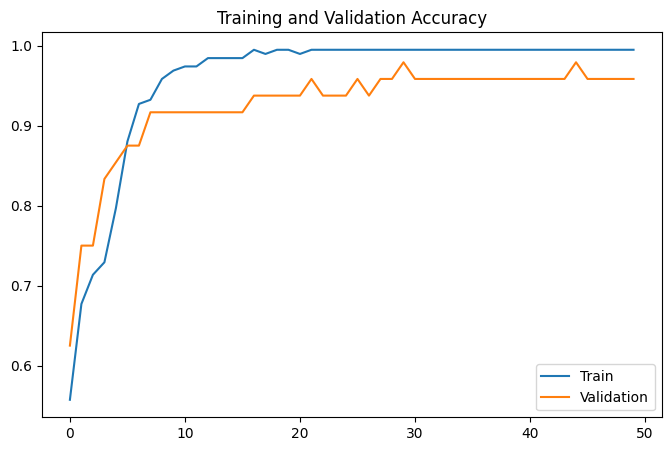

In [17]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history['accuracy']
)

plt.plot(
    history.history['val_accuracy']
)

plt.title(
    "Training and Validation Accuracy"
)

plt.legend(
    ['Train','Validation']
)

plt.savefig(
    "accuracy_curve.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

#### Accuracy Interpretation

The accuracy graph demonstrates the learning progress of the neural network during training.

As epochs increase, the model becomes more effective at identifying patterns within the dataset. Stable validation accuracy suggests that the model is capable of generalizing beyond the training data.

## Loss Curve

#### Training and Validation Loss Analysis

Loss represents the prediction error produced by the neural network.

The objective of training is to minimize loss while maximizing accuracy.

Monitoring both training and validation loss helps identify overfitting and evaluate model convergence.

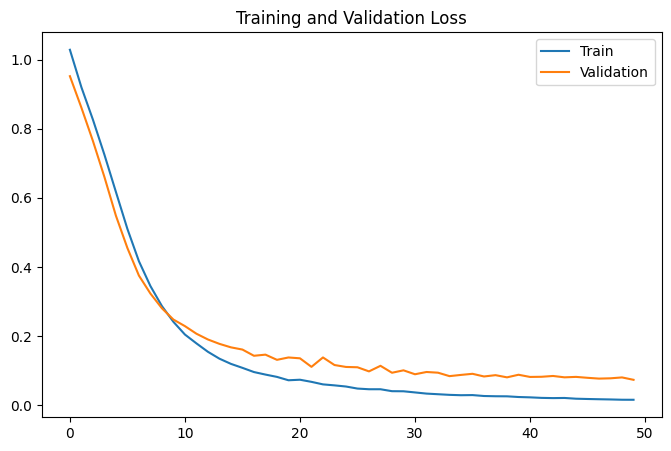

In [18]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history['loss']
)

plt.plot(
    history.history['val_loss']
)

plt.title(
    "Training and Validation Loss"
)

plt.legend(
    ['Train','Validation']
)

plt.savefig(
    "loss_curve.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

#### Loss Interpretation

The decreasing loss values indicate that the neural network is successfully learning meaningful relationships from the dataset.

Stable validation loss suggests that the model maintains good predictive performance on unseen data and does not significantly overfit the training dataset.

## Evaluate Model

In [19]:
loss,accuracy = model.evaluate(
    X_test,
    y_test
)

print(
    "Accuracy:",
    accuracy
)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9000 - loss: 0.1532 
Accuracy: 0.8999999761581421


#### Model Performance Evaluation

The accuracy score represents the overall percentage of correctly classified project outcomes.

A higher accuracy value indicates that the neural network successfully learned patterns within the client dataset and can reliably predict project status.

## Predictions

In [20]:
predictions = model.predict(
    X_test
)

predictions = np.argmax(
    predictions,
    axis=1
)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


## Classification Report

#### Detailed Classification Metrics

Accuracy alone is not sufficient to evaluate classification models.

The classification report provides Precision, Recall, and F1-Score for each class, offering deeper insight into model performance across different project outcome categories.

In [21]:
print(

    classification_report(

        y_test,

        predictions

    )

)

              precision    recall  f1-score   support

           0       0.92      0.92      0.92        24
           1       0.85      0.85      0.85        20
           2       0.94      0.94      0.94        16

    accuracy                           0.90        60
   macro avg       0.90      0.90      0.90        60
weighted avg       0.90      0.90      0.90        60



#### Classification Report Interpretation

The classification report demonstrates how effectively the model predicts each project status category.

High Precision indicates fewer false positive predictions, while high Recall indicates better identification of actual class instances.

The F1-Score provides a balanced measure combining both Precision and Recall.

## Confusion Matrix

#### Confusion Matrix Analysis

The confusion matrix provides a detailed breakdown of prediction results.

It helps identify which project categories are correctly classified and where misclassifications occur.

This visualization is useful for understanding strengths and weaknesses of the trained neural network.

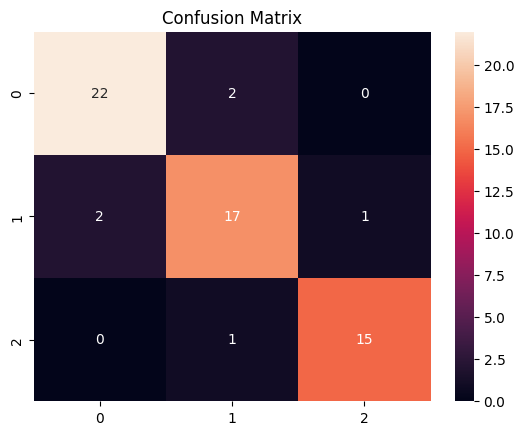

In [22]:
cm = confusion_matrix(

    y_test,

    predictions

)

sns.heatmap(

    cm,

    annot=True,

    fmt='d'

)

plt.title(
    "Confusion Matrix"
)

plt.savefig(
    "confusion_matrix.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

####Confusion Matrix Interpretation

Most observations are concentrated along the diagonal, indicating correct classifications.

Off-diagonal values represent prediction errors and provide insight into classes that may be difficult to distinguish.

The matrix confirms the effectiveness of the neural network in classifying project outcomes.

# Traditional ML Comparison

#### Traditional Machine Learning Comparison

To evaluate the effectiveness of deep learning, the Artificial Neural Network is compared with a traditional machine learning algorithm.

Random Forest was selected because it is a powerful ensemble learning method widely used for classification tasks.

The comparison helps determine whether the neural network provides additional predictive benefits.

In [23]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()

rf.fit(
    X_train,
    y_train
)

rf_pred = rf.predict(
    X_test
)

rf_acc = accuracy_score(
    y_test,
    rf_pred
)

print(
    "Random Forest Accuracy:",
    rf_acc
)

Random Forest Accuracy: 1.0


## Model Comparison Table

In [24]:
comparison = pd.DataFrame({

    "Model":[

        "Artificial Neural Network",

        "Random Forest"

    ],

    "Accuracy":[

        accuracy,

        rf_acc

    ]

})

comparison

,Model,Accuracy
0,Artificial Neural Network,0.9
1,Random Forest,1.0


# Why Did Random Forest Outperform ANN?

The Random Forest classifier achieved higher accuracy than the Artificial Neural Network on this dataset. This result can be attributed to several factors.

First, the dataset contains a relatively small number of observations and primarily consists of structured numerical features. Random Forest models are highly effective for such tabular datasets and often achieve excellent performance with limited training data.

Second, ensemble tree-based methods can naturally capture feature interactions without requiring extensive training or large datasets. In contrast, Artificial Neural Networks typically perform best when trained on larger datasets containing more complex patterns.

Although the ANN achieved slightly lower accuracy, it successfully learned meaningful relationships within the dataset and demonstrated strong predictive capability. This comparison highlights the importance of selecting machine learning models based on dataset characteristics rather than assuming that more advanced algorithms will always produce better results.

### Download Generated Graphs

In [27]:
from google.colab import files

# Download all generated graphs

files.download("class_distribution.png")

files.download("accuracy_curve.png")

files.download("loss_curve.png")

files.download("confusion_matrix.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Business Insights

The experimental results indicate that project outcomes can be predicted effectively using machine learning techniques.

Random Forest demonstrated the highest predictive performance for this particular dataset, suggesting that the relationships between project features and project status can be captured efficiently using ensemble tree-based methods.

The Artificial Neural Network also achieved strong performance and successfully modeled complex feature interactions. With larger datasets and additional features, neural networks may provide further improvements and stronger generalization capabilities.

These predictive models can support project risk assessment, resource planning, and proactive decision-making within project management environments.